### **ICESat数据查看**

In [15]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from pyrsimg import readTiff, imgShow, second_to_dyr


In [16]:
path_glah14 = 'data/icesat/GLAH14_634_2125_001_1317_0_01_0001.H5'
path_rsimg = 'data/rsimg/setp_glacier_20200510_wgs84.tif'


In [17]:
!h5ls $path_glah14/Data_1HZ
# !h5ls $path_glah14/Data_1HZ/Geolocation/i_track
# !h5ls $path_glah14/Data_40HZ/Elevation_Surfaces


Atmosphere               Group
DS_UTCTime_1             Dataset {26321/Inf}
Elevation_Flags          Group
Geolocation              Group
Packet_data              Group
Quality                  Group
Reflectivity             Group
Time                     Group
Transmit_Energy          Group


In [19]:
with h5py.File(path_glah14,'r') as setp_glah14:
    lat = setp_glah14['Data_40HZ/Geolocation/d_lat'][:]
    lon = setp_glah14['Data_40HZ/Geolocation/d_lon'][:]
    elev = setp_glah14['Data_40HZ/Elevation_Surfaces/d_elev'][:]
    time = setp_glah14['Data_40HZ/Time/d_UTCTime_40'][:]
time = second_to_dyr(time)
## 2. remote sensing image
rsimg = readTiff(path_rsimg)


array([2008.76330755, 2008.76330755, 2008.76330755, ..., 2008.76580369,
       2008.76580369, 2008.76580369])

In [11]:
idx = np.where((abs(lat)<90) & (lon<360) & (lon>0)) 
lat, lon, elev = lat[idx], lon[idx], elev[idx]



Text(0.5, 1.0, 'jason-3')

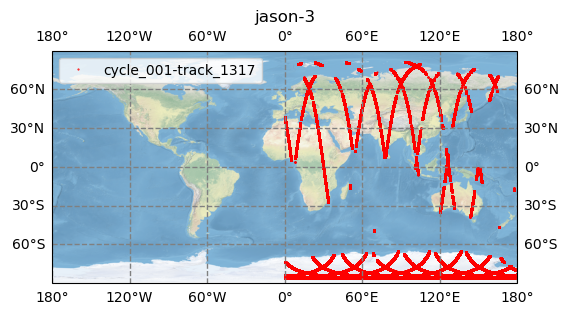

In [12]:
proj = ccrs.PlateCarree(central_longitude=0.0)
fig = plt.figure(figsize=(6, 6))
cycle, track_start = path_glah14.split('/')[-1].split('_')[3], path_glah14.split('/')[-1].split('_')[4]
orbit_isat = 'cycle_'+str(cycle)+'-track_'+str(track_start)
## jason-3
ax3 = fig.add_subplot(111, projection=proj); 
ax3.stock_img()
ax3.plot(lon, lat, marker='.', markersize=1, linewidth=0.0, label=orbit_isat, color='red')
ax3.gridlines(draw_labels=True, linewidth=1, color='gray', linestyle='--')
ax3.legend(); 
plt.title('jason-3')


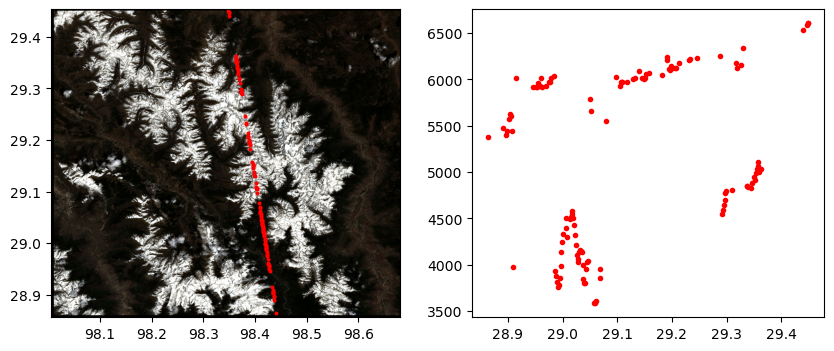

In [21]:
ids = np.where((lat>28.86) & (lat<29.45) & (lon >98) & (lon<98.69))
fig, ax = plt.subplots(1,2, figsize=(10, 4))
imgShow(rsimg.array, extent=rsimg.geoextent, clip_percent=5, ax=ax[0])
ax[0].scatter(x=lon[ids], y=lat[ids], s=3.5, color='red')  
ax[1].plot(lat[ids], elev[ids], 'r.')

